In [1]:
import jetfuelburn
from jetfuelburn import ureg

In [2]:
from jetfuelburn.reducedorder import seymour_etal

In [3]:
fuel_seymour = seymour_etal.calculate_fuel_consumption(
    acft="A333",
    R=7000 * ureg.km,
)

In [4]:
from jetfuelburn.reducedorder import sacchi_etal
from jetfuelburn.reducedorder import yanto_etal

In [5]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sweep parameters
weightloss_coeffs = [0.15, 0.18]  # body-weight reduction for ozempic users
ozempic_fractions = [0.08, 0.10, 0.12, 0.14, 0.16]  # share of passengers on ozempic

# Fixed flight / aircraft parameters
pax_max = 440
loadfactor = 0.835  # Montlaur load factor (used in sacchi)
pax_nmbr = 260  # absolute pax count (used in yanto)
weight_per_pax = 100 * ureg.kg
R = 7000 * ureg.km
CO2_FACTOR = 3.16  # kg CO2 per kg jet fuel
FUEL_COST_PER_KG = 1.4  # USD per kg (1400 USD per 1000 kg)

In [6]:
# Baselines (no ozempic)
fuel_sacchi_base = sacchi_etal.calculate_fuel_consumption(
    year=2024,
    pax_max=pax_max,
    pax=pax_max * loadfactor,
    R=R,
)
fuel_yanto_base = yanto_etal.calculate_fuel_consumption(
    acft="A333",
    R=R,
    PL=pax_nmbr * weight_per_pax,
)

records = []
for wl, oz in itertools.product(weightloss_coeffs, ozempic_fractions):
    # sacchi: ozempic reduces effective pax weight → modelled as fewer equivalent pax
    pax_oz = pax_max * loadfactor * (1 - wl * oz)
    fuel_sacchi_oz = sacchi_etal.calculate_fuel_consumption(
        year=2024,
        pax_max=pax_max,
        pax=pax_oz,
        R=R,
    )
    sacchi_fuel_diff = (fuel_sacchi_base - fuel_sacchi_oz).to("kg").magnitude
    sacchi_co2_diff = sacchi_fuel_diff * CO2_FACTOR
    sacchi_cost_diff = sacchi_fuel_diff * FUEL_COST_PER_KG

    # yanto: ozempic users weigh less → mixed payload
    weight_oz = weight_per_pax * (1 - wl)
    payload_oz = pax_nmbr * ((1 - oz) * weight_per_pax + oz * weight_oz)
    fuel_yanto_oz = yanto_etal.calculate_fuel_consumption(
        acft="A333",
        R=R,
        PL=payload_oz,
    )
    yanto_fuel_diff = (fuel_yanto_base - fuel_yanto_oz).to("kg").magnitude
    yanto_co2_diff = yanto_fuel_diff * CO2_FACTOR
    yanto_cost_diff = yanto_fuel_diff * FUEL_COST_PER_KG

    records.append(
        {
            "weightloss_coeff": wl,
            "people_on_ozempic": oz,
            "sacchi_fuel_diff_kg": sacchi_fuel_diff,
            "sacchi_co2_diff_kg": sacchi_co2_diff,
            "sacchi_cost_diff_usd": sacchi_cost_diff,
            "yanto_fuel_diff_kg": yanto_fuel_diff,
            "yanto_co2_diff_kg": yanto_co2_diff,
            "yanto_cost_diff_usd": yanto_cost_diff,
        }
    )

df = pd.DataFrame(records)
print(df.to_string(index=False))

 weightloss_coeff  people_on_ozempic  sacchi_fuel_diff_kg  sacchi_co2_diff_kg  sacchi_cost_diff_usd  yanto_fuel_diff_kg  yanto_co2_diff_kg  yanto_cost_diff_usd
             0.15               0.08           203.376014          642.668203            284.726419            102.6480         324.367680            143.70720
             0.15               0.10           254.223905          803.347540            355.913467            128.3100         405.459600            179.63400
             0.15               0.12           305.073354          964.031799            427.102696            153.9720         486.551520            215.56080
             0.15               0.14           355.924362         1124.720983            498.294107            179.6340         567.643440            251.48760
             0.15               0.16           406.776930         1285.415098            569.487702            205.2960         648.735360            287.41440
             0.18               0.08    

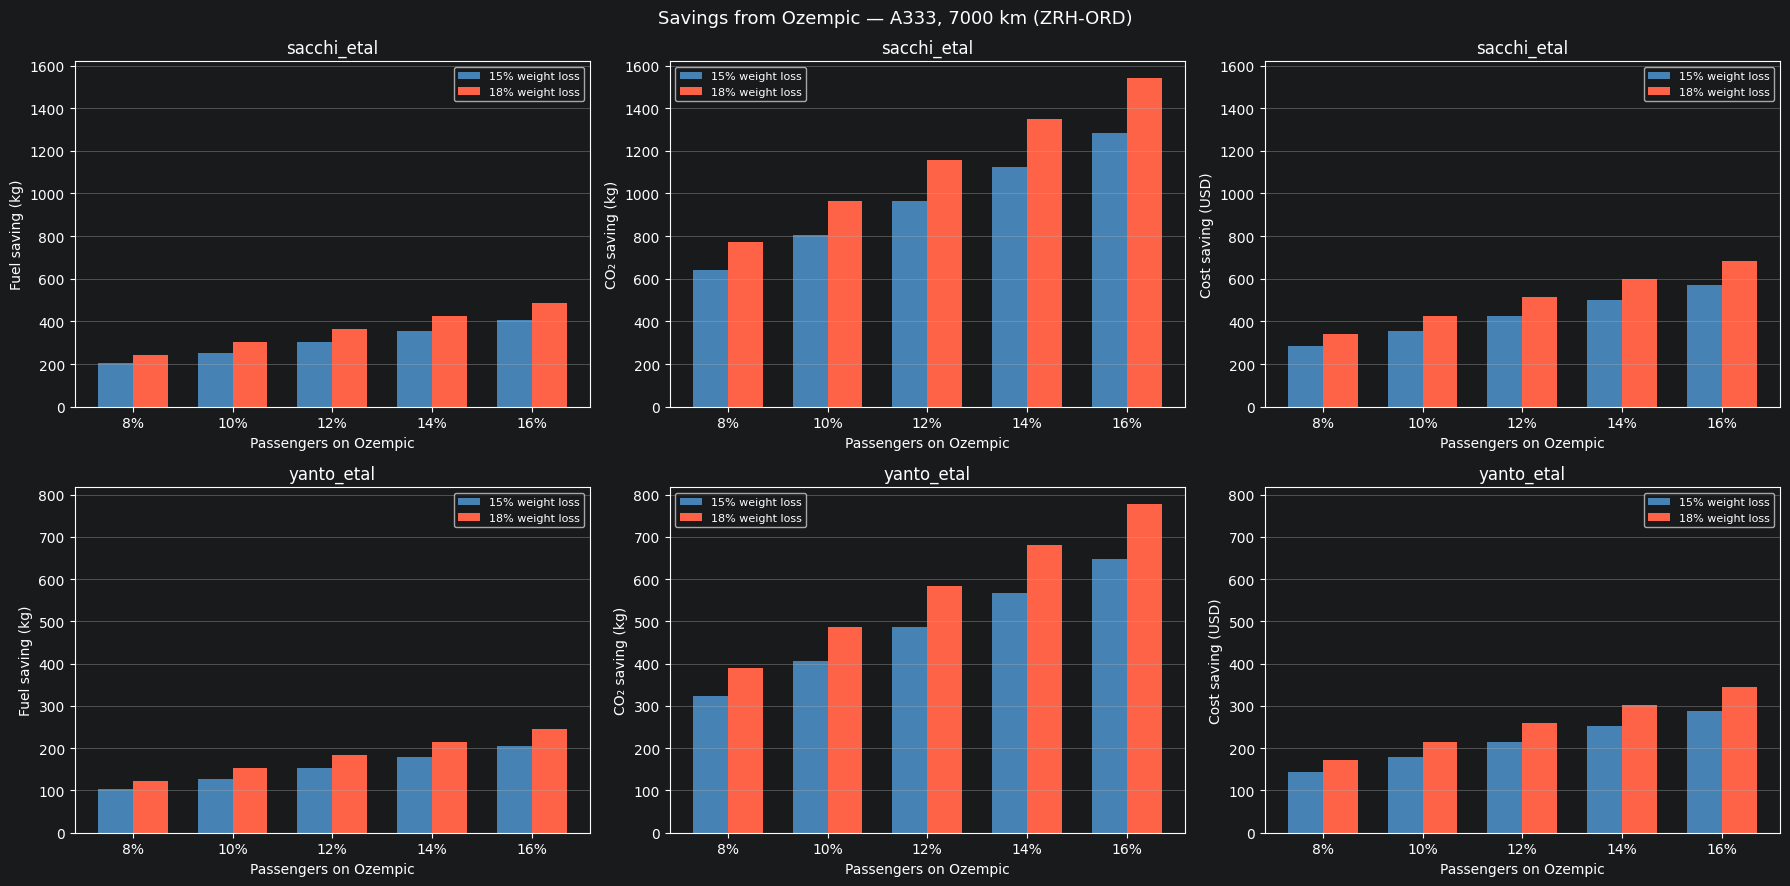

In [7]:
x = np.arange(len(ozempic_fractions))
width = 0.35
labels = [f"{int(oz * 100)}%" for oz in ozempic_fractions]
colors = ["steelblue", "tomato"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey="row")
fig.suptitle("Savings from Ozempic — A333, 7000 km (ZRH-ORD)", fontsize=13)

metrics = [
    (
        "sacchi_etal",
        "sacchi_fuel_diff_kg",
        "sacchi_co2_diff_kg",
        "sacchi_cost_diff_usd",
    ),
    ("yanto_etal", "yanto_fuel_diff_kg", "yanto_co2_diff_kg", "yanto_cost_diff_usd"),
]

for row_idx, (model, fuel_col, co2_col, cost_col) in enumerate(metrics):
    for col_idx, (metric, ylabel) in enumerate(
        [
            (fuel_col, "Fuel saving (kg)"),
            (co2_col, "CO₂ saving (kg)"),
            (cost_col, "Cost saving (USD)"),
        ]
    ):
        ax = axes[row_idx][col_idx]
        for i, wl in enumerate(weightloss_coeffs):
            subset = df[df["weightloss_coeff"] == wl].sort_values("people_on_ozempic")
            ax.bar(
                x + (i - 0.5) * width,
                subset[metric].values,
                width,
                label=f"{int(wl * 100)}% weight loss",
                color=colors[i],
            )
        ax.set_title(f"{model}")
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Passengers on Ozempic")
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.tick_params(labelleft=True)
        ax.legend(fontsize=8)
        ax.grid(axis="y", linewidth=0.5)

plt.tight_layout()
plt.show()

In [8]:
from jetfuelburn.reducedorder import montlaur_etal

In [9]:
fuel3 = montlaur_etal.calculate_fuel_consumption(
    distance=7000 * ureg.km,
    available_seats=320,
)
fuel_montlaur = fuel3 * 7.0 * 320